In [20]:
detach("package:SCOUT", unload = TRUE)

In [22]:
library(SCOUT)
library(progressr)
library(future.apply)
library(corpcor)
library(paleotree)
library(nloptr)
library(dplyr)
library(stringr)

suppressPackageStartupMessages({
  library(castor); library(ape); library(expm); library(Matrix); library(paleotree)
  library(ggplot2); library(reshape2)
})

source('../../cellfatebias/scripts/utilities.R')

In [31]:
#library(roxygen2)
#library(devtools)

In [6]:
setwd('/dartfs/rc/lab/M/McKennaLab/projects/hannah/OU/revisions_analysis')

In [7]:
tree <- ape::read.tree('./simulation_revisions/260323_dropout/character_mats/260323_dropout_n256_TedSim_character_matrix_casNJ_tree.nwk')

In [8]:
set.seed(1)
ncells <- 100
P <- matrix(c(0.90, 0.08, 0.02,
              0.10, 0.80, 0.10,
              0.02, 0.08, 0.90),
            3, 3,
            byrow = T)
Q <- expm::logm(P)

simtree.obj <- generate_tree_hbd_reverse(ncells, rho = 1, lambda = 1, mu = 0)
states  <- castor::simulate_mk_model(simtree.obj$trees[[1]], Q = Q, include_nodes = FALSE)
simtree <- simtree.obj$trees[[1]]
simtree$tip.label <- paste0('t', simtree$tip.label)
simtree$states    <- as.factor(paste0('state', states$tip_states))
simtree <- infer_anc(simtree)
table(simtree$states)


state1 state2 state3 
    42     14     44 

ggtree v4.3.0 Learn more at https://yulab-smu.top/contribution-tree-data/

Please cite:

Guangchuang Yu, David Smith, Huachen Zhu, Yi Guan, Tommy Tsan-Yuk Lam.
ggtree: an R package for visualization and annotation of phylogenetic
trees with their covariates and other associated data. Methods in
Ecology and Evolution. 2017, 8(1):28-36. doi:10.1111/2041-210X.12628


Attaching package: ‘ggtree’


The following object is masked from ‘package:Matrix’:

    expand


The following object is masked from ‘package:ape’:

    rotate




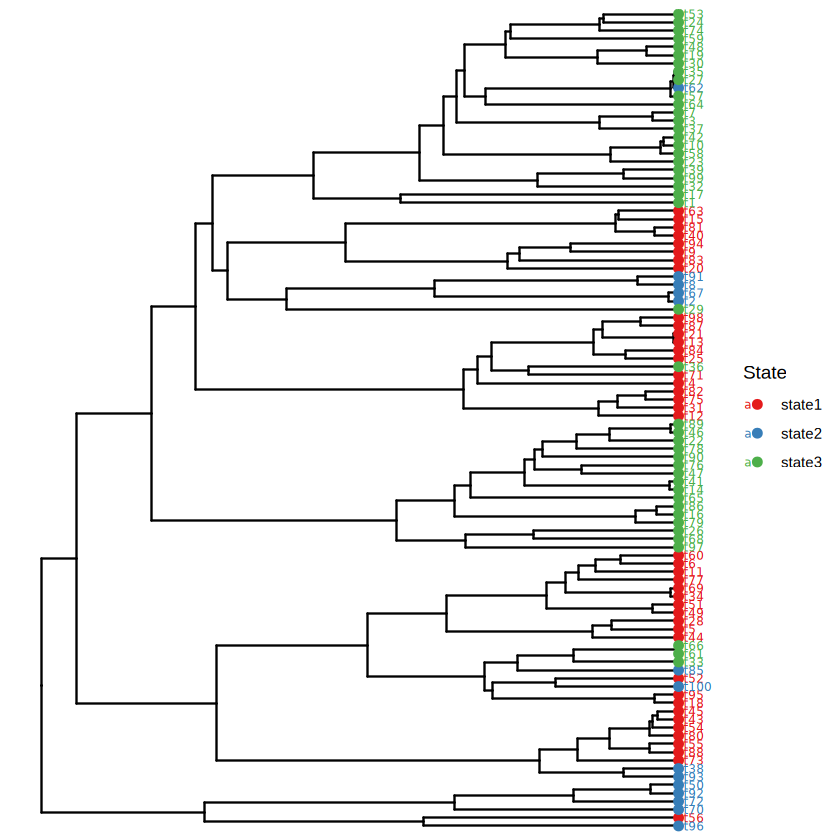

In [9]:
plot_tree_states(simtree)

In [34]:
int_tree <- ape::read.tree( './revision_v2/1_tree_robustness/data/260804_simtree_100cells_hbd_rev_w_internal_nodes.nwk')
int_tree$states <- simtree$states
simtest <- simulate_test_data(30, ncells, int_tree, 
                   outdir = './revision_v2/1_tree_robustness/data/', 
                   out_prefix = '260804_simtree_100cells_hbd_rev',
                   a = 3, s = 1, t0 = 3, theta_step = 2, sim_lin=FALSE)

2026-08-05 16:00:03.978002 | Simulating OU genes for 1 parameter combinations.

2026-08-05 16:00:06.005138 | Data generation complete



In [25]:
ape::write.tree(simtree, './revision_v2/1_tree_robustness/data/260804_simtree_100cells_hbd_rev_w_internal_nodes.nwk')
simtree$node.label <- NULL
ape::write.tree(simtree, './revision_v2/1_tree_robustness/data/260804_simtree_100cells_hbd_rev.nwk')

In [36]:
scout.res <- SCOUT(counts.file = './revision_v2/1_tree_robustness/data/260804_simtree_100cells_hbd_rev_alpha_3_sigma_1_OUEVF_counts.csv',
    tree.file = './revision_v2/1_tree_robustness/data/260804_simtree_100cells_hbd_rev.nwk',
    results_dir = "../../revisions_analysis/revision_v2/1_tree_robustness/output/1_260804_simtree_100cells_hbd_rev_SCALETREE",
    regimes = c("BM1", "OU1", "OUM"),
    cores = 32, 
    scale_tree = TRUE, 
    logfile = './revision_v2/1_tree_robustness/logs/1_260804_simtree_100cells_hbd_rev_SCALETREE.log', 
    verbose=TRUE
)

Directory already exists: ../../revisions_analysis/revision_v2/1_tree_robustness/output/1_260804_simtree_100cells_hbd_rev_SCALETREE 


2026-08-05 16:00:33.175172 | Started logging @ ./revision_v2/1_tree_robustness/logs/1_260804_simtree_100cells_hbd_rev_SCALETREE.log

2026-08-05 16:00:33.181579 | Data will be saved to --> ../../revisions_analysis/revision_v2/1_tree_robustness/output/1_260804_simtree_100cells_hbd_rev_SCALETREE

2026-08-05 16:00:33.20558 | =========================================================


2026-08-05 16:00:33.236865 | Inferring gene list from input data columns.

2026-08-05 16:00:33.247995 | 90 genes were detected. 

2026-08-05 16:00:33.256896 | 100 leaves were found in the raw tree. 100 leaves intersect with species column.

2026-08-05 16:00:33.263179 | Preprocessing tree

2026-08-05 16:00:33.265388 | Found edge lengths.

2026-08-05 16:00:33.267812 | 2026-08-05 16:00:33.26782 Log normalizing gene expression counts.

2026-08-05 16:00:33.278489 | Regime: BM1 Rcol: OU1 Model: BM1

2026-08-05 16:00:33.281318 | Regime: OU1 Rcol: OU1 Model: OU1

2026-08-05 16:00:33.474463 | Regime: OUM Rcol: OUM Mode

Running 270 combinations. Results will be saved at run ID = SCOUT_04CXqUJ6 


2026-08-05 16:00:35.471243 | Start time = 16:00:35


2026-08-05 16:06:53.488501 | End time = 16:06:53


2026-08-05 16:06:54.219804 | Done with initial analysis of SCOUT_04CXqUJ6.

2026-08-05 16:06:54.227894 | =========================================================


2026-08-05 16:06:54.23387 | Processsing Results... Saving files to ../../revisions_analysis/revision_v2/1_tree_robustness/output/1_260804_simtree_100cells_hbd_rev_SCALETREE



In [37]:
scout.res$SCOUT_class$truth <- str_extract(scout.res$SCOUT_class$gene_name, 'BM1|OU1|OUM')

table(scout.res$SCOUT_class$truth, scout.res$SCOUT_class$model)

     
      BM1 OU1 OUM
  BM1  28   1   1
  OU1  10  14   6
  OUM   6   0  24

In [40]:
scout.res.evf <- SCOUT(counts.file = './revision_v2/1_tree_robustness/data/260804_simtree_100cells_hbd_rev_alpha_3_sigma_1_OUEVF_evf_counts.csv',
    tree.file = './revision_v2/1_tree_robustness/data/260804_simtree_100cells_hbd_rev.nwk',
    results_dir = "../../revisions_analysis/revision_v2/1_tree_robustness/output/1_260804_simtree_100cells_hbd_rev_SCALETREE_evf",
    regimes = c("BM1", "OU1", "OUM"),
    cores = 32, 
    normalize = FALSE, 
    scale_tree = TRUE, 
    logfile = './revision_v2/1_tree_robustness/logs/1_260804_simtree_100cells_hbd_rev_SCALETREE_evf.log', 
    verbose=TRUE
)

Directory already exists: ../../revisions_analysis/revision_v2/1_tree_robustness/output/1_260804_simtree_100cells_hbd_rev_SCALETREE_evf 


2026-08-05 16:10:15.711251 | Started logging @ ./revision_v2/1_tree_robustness/logs/1_260804_simtree_100cells_hbd_rev_SCALETREE_evf.log

2026-08-05 16:10:15.714266 | Data will be saved to --> ../../revisions_analysis/revision_v2/1_tree_robustness/output/1_260804_simtree_100cells_hbd_rev_SCALETREE_evf

2026-08-05 16:10:15.719718 | =========================================================


2026-08-05 16:10:15.773556 | Inferring gene list from input data columns.

2026-08-05 16:10:15.779753 | 60 genes were detected. 

2026-08-05 16:10:15.792141 | 100 leaves were found in the raw tree. 100 leaves intersect with species column.

2026-08-05 16:10:15.799109 | Preprocessing tree

2026-08-05 16:10:15.801257 | Found edge lengths.

2026-08-05 16:10:15.804085 | Regime: BM1 Rcol: OU1 Model: BM1

2026-08-05 16:10:15.805995 | Regime: OU1 Rcol: OU1 Model: OU1

2026-08-05 16:10:16.013777 | Regime: OUM Rcol: OUM Model: OUM



Running 180 combinations. Results will be saved at run ID = SCOUT_GHemqCZ0 


2026-08-05 16:10:16.384713 | Start time = 16:10:16


2026-08-05 16:14:39.671572 | End time = 16:14:39


2026-08-05 16:14:40.169946 | Done with initial analysis of SCOUT_GHemqCZ0.

2026-08-05 16:14:40.185814 | =========================================================


2026-08-05 16:14:40.197677 | Processsing Results... Saving files to ../../revisions_analysis/revision_v2/1_tree_robustness/output/1_260804_simtree_100cells_hbd_rev_SCALETREE_evf



In [41]:
scout.res.evf$SCOUT_class$truth <- str_extract(scout.res.evf$SCOUT_class$gene_name, 'BM1|OU1|OUM')

table(scout.res.evf$SCOUT_class$truth, scout.res.evf$SCOUT_class$model)

     
      BM1 OU1 OUM
  BM1  20   0   0
  OU1  10   7   3
  OUM   0   0  20

In [44]:
caret::confusionMatrix(data = as.factor(scout.res.evf$SCOUT_class$model), 
                       reference = as.factor(scout.res.evf$SCOUT_class$truth), 
                       mode = "everything", positive = "1")


Confusion Matrix and Statistics

          Reference
Prediction BM1 OU1 OUM
       BM1  20  10   0
       OU1   0   7   0
       OUM   0   3  20

Overall Statistics
                                         
               Accuracy : 0.7833         
                 95% CI : (0.658, 0.8793)
    No Information Rate : 0.3333         
    P-Value [Acc > NIR] : 1.152e-12      
                                         
                  Kappa : 0.675          
                                         
 Mcnemar's Test P-Value : NA             

Statistics by Class:

                     Class: BM1 Class: OU1 Class: OUM
Sensitivity              1.0000     0.3500     1.0000
Specificity              0.7500     1.0000     0.9250
Pos Pred Value           0.6667     1.0000     0.8696
Neg Pred Value           1.0000     0.7547     1.0000
Precision                0.6667     1.0000     0.8696
Recall                   1.0000     0.3500     1.0000
F1                       0.8000     0.5185     0.9302
Pr